# POF power-scan PSD and SNR analysis

This notebook analyzes the 20260709 POF data set by looking at each power level, plotting the PSD of the signal and noise for every available voltage scan, and computing SNR values for each scan.

In [79]:
import os
import re
import sys

sys.path.append("../")

import analysis
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
from scipy.signal import periodogram

base_path = r"C:\Users\sl57562\The University of Texas at Austin\Acoustic + Calcium - Documents\Acoustic\pof_first_data_set_20260709\20260709"

In [ ]:

def analyze_power_level(power_mw, base_path, band_half_width_hz=1e3):
    power_pattern = f"pof_{power_mw}mW"
    noise_folder = f"{power_pattern}_noise"

    voltage_scans = [
        (float(re.search(r"_(\d+(?:\.\d+)?)V$", folder).group(1)), folder)
        for folder in os.listdir(base_path)
        if os.path.isdir(os.path.join(base_path, folder))
        and folder.startswith(f"{power_pattern}_")
        and "noise" not in folder
        and re.search(r"_(\d+(?:\.\d+)?)V$", folder)
    ]
    voltage_scans.sort(key=lambda item: item[0], reverse=True)
    voltage_folders = [folder for _, folder in voltage_scans]

    if not voltage_scans:
        raise ValueError(f"No voltage scan folders found for {power_pattern}")

    print(f"Analyzing {power_pattern}: found {len(voltage_scans)} voltage scans")

    rows, cols = 4, 3
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows), squeeze=False)
    axes = axes.flatten()

    results = {}

    for ax, (voltage_value, voltage_folder) in zip(axes, voltage_scans):
        frequency_match = re.search(r"_(\d+(?:\.\d+)?)kHz_", voltage_folder)
        if frequency_match is None:
            continue

        center_frequency_hz = float(frequency_match.group(1)) * 1e3 
        signal_path = os.path.join(base_path, voltage_folder)
        noise_path = os.path.join(base_path, noise_folder)

        signal_files = [
            os.path.join(signal_path, f"iter_{x}.tdms")
            for x in range(5) #drop to 5 to exclude data thats further drifted from alignement
            if os.path.exists(os.path.join(signal_path, f"iter_{x}.tdms"))
        ]
        noise_files = [
            os.path.join(noise_path, f"iter_{x}.tdms")
            for x in range(5) #drop to 5 to exclude data thats further drifted from alignement
            if os.path.exists(os.path.join(noise_path, f"iter_{x}.tdms"))
        ]

        if not signal_files or not noise_files:
            print(f"Skipping {voltage_folder}: missing signal or noise files")
            continue

        print(f"  Processing {voltage_folder} with {len(signal_files)} signal files and {len(noise_files)} noise files")

        system = analysis.System(
            f"{power_pattern}_{voltage_folder}",
            signal_files + noise_files,
            channel="X",
            set_data=True,
        )

        freqs = None
        signal_psds = []
        noise_psds = []

        for dataset_idx, dataset in enumerate(system.get_data()):
            dataset.apply("detrend", mode="linear", inplace=True)

            group = "signal" if dataset_idx < len(signal_files) else "noise"

            for collection in dataset.collection:
                sample_rate = getattr(dataset, "r", None)
                if freqs is None:
                    #freqs, psd = welch(collection.x, sample_rate, nfft=2**15, nperseg=2**14)
                    freqs, psd = periodogram(collection.x, sample_rate, nfft=2**15)
                else:
                    #_, psd = welch(collection.x, sample_rate, nfft=2**15, nperseg=2**14)
                    _, psd = periodogram(collection.x, sample_rate, nfft=2**15)

                if group == "signal":
                    signal_psds.append(psd)
                else:
                    noise_psds.append(psd)

        avg_freqs = freqs
        avg_signal_psd = np.mean(np.asarray(signal_psds), axis=0)
        avg_noise_psd = np.mean(np.asarray(noise_psds), axis=0)

        band_min_idx = np.searchsorted(avg_freqs, center_frequency_hz - band_half_width_hz)
        band_max_idx = np.searchsorted(avg_freqs, center_frequency_hz + band_half_width_hz)
        print(
            f"    In-band bounds (Hz): {avg_freqs[band_min_idx]:.0f} to {avg_freqs[max(band_max_idx - 1, band_min_idx)]:.0f}"
        )

        wideband_signal_power = np.trapezoid(avg_signal_psd, avg_freqs)
        wideband_noise_power = np.trapezoid(avg_noise_psd, avg_freqs)
        snr_wideband = 10 * np.log10(wideband_signal_power / wideband_noise_power)

        inband_signal_power = np.trapezoid(
            avg_signal_psd[band_min_idx:band_max_idx],
            avg_freqs[band_min_idx:band_max_idx],
        )
        inband_noise_power = np.trapezoid(
            avg_noise_psd[band_min_idx:band_max_idx],
            avg_freqs[band_min_idx:band_max_idx],
        )
        snr_inband = 10 * np.log10(inband_signal_power / inband_noise_power)

        results[voltage_value] = {
            "freqs": avg_freqs,
            "signal": avg_signal_psd,
            "noise": avg_noise_psd,
            "snr_wideband": snr_wideband,
            "snr_inband": snr_inband,
            "band_min_idx": band_min_idx,
            "band_max_idx": band_max_idx,
        }
        def calculate_NEP(snr_inband, voltage_value):
            stroke_distance = [0.05, 0.09, 0.14, 0.19, 0.24, 0.30, 0.35, 0.40, 0.46, 0.44] #stroke distance in nm
            rho = 1.2041 #kg/m^3 at 21 degrees C, desnity of air
            c = 343.21 #m/2 @ 21 degrees C, speed of sound in air
            f = center_frequency_hz
            omega = 2*np.pi*f
            X_o = stroke_distance[int(voltage_value-1)] * 1e-9
            P = rho*c*omega*X_o
            if snr_inband < 1.0:
                NEP = "Null"
            else:
                NEP = P / snr_inband 
                NEP = round(NEP, 4)
            return NEP


        ax.loglog(avg_freqs, avg_signal_psd, label="Signal", alpha=0.7)
        ax.loglog(avg_freqs, avg_noise_psd, label="Noise", alpha=0.7)
        # ax.axvline(avg_freqs[band_min_idx], color="k", linestyle="--", linewidth=0.5)
        # ax.axvline(avg_freqs[max(band_max_idx - 1, band_min_idx)], color="k", linestyle="--", linewidth=0.5)
        ax.set_title(f"{voltage_value} V\nIn-band SNR: {snr_inband:.1f} dB\nNEP: {calculate_NEP(snr_inband, voltage_value)} Pa")
        ax.set_xlabel("Frequency (Hz)")
        ax.set_ylabel("PSD")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=7)
        ax.set_ylim(1e-16, 1e-6)

        print(f"    In-band SNR: {snr_inband:.2f} dB | Wideband SNR: {snr_wideband:.2f} dB")
        print(f"    NEP: {calculate_NEP(snr_inband, voltage_value)} Pa")

    for ax in axes[len(results):]:
        ax.set_visible(False)

    fig.suptitle(f"{power_mw} mW PSDs and SNRs")
    fig.tight_layout()
    plt.show()

    return results




Analyzing pof_21mW: found 10 voltage scans
  Processing pof_21mW_109kHz_10V with 5 signal files and 5 noise files
    In-band bounds (Hz): 108337 to 109863
    In-band SNR: 5.38 dB | Wideband SNR: 0.05 dB
    NEP: 0.0231 Pa
  Processing pof_21mW_109kHz_9V with 5 signal files and 5 noise files
    In-band bounds (Hz): 108337 to 109863
    In-band SNR: 7.43 dB | Wideband SNR: 0.07 dB
    NEP: 0.0175 Pa
  Processing pof_21mW_109kHz_8V with 5 signal files and 5 noise files
    In-band bounds (Hz): 108337 to 109863
    In-band SNR: 6.67 dB | Wideband SNR: 0.06 dB
    NEP: 0.017 Pa
  Processing pof_21mW_109kHz_7V with 5 signal files and 5 noise files
    In-band bounds (Hz): 108337 to 109863
    In-band SNR: 5.12 dB | Wideband SNR: 0.09 dB
    NEP: 0.0193 Pa
  Processing pof_21mW_109kHz_6V with 5 signal files and 5 noise files
    In-band bounds (Hz): 108337 to 109863
    In-band SNR: 3.33 dB | Wideband SNR: 0.10 dB
    NEP: 0.0255 Pa
  Processing pof_21mW_109kHz_5V with 5 signal files and 5

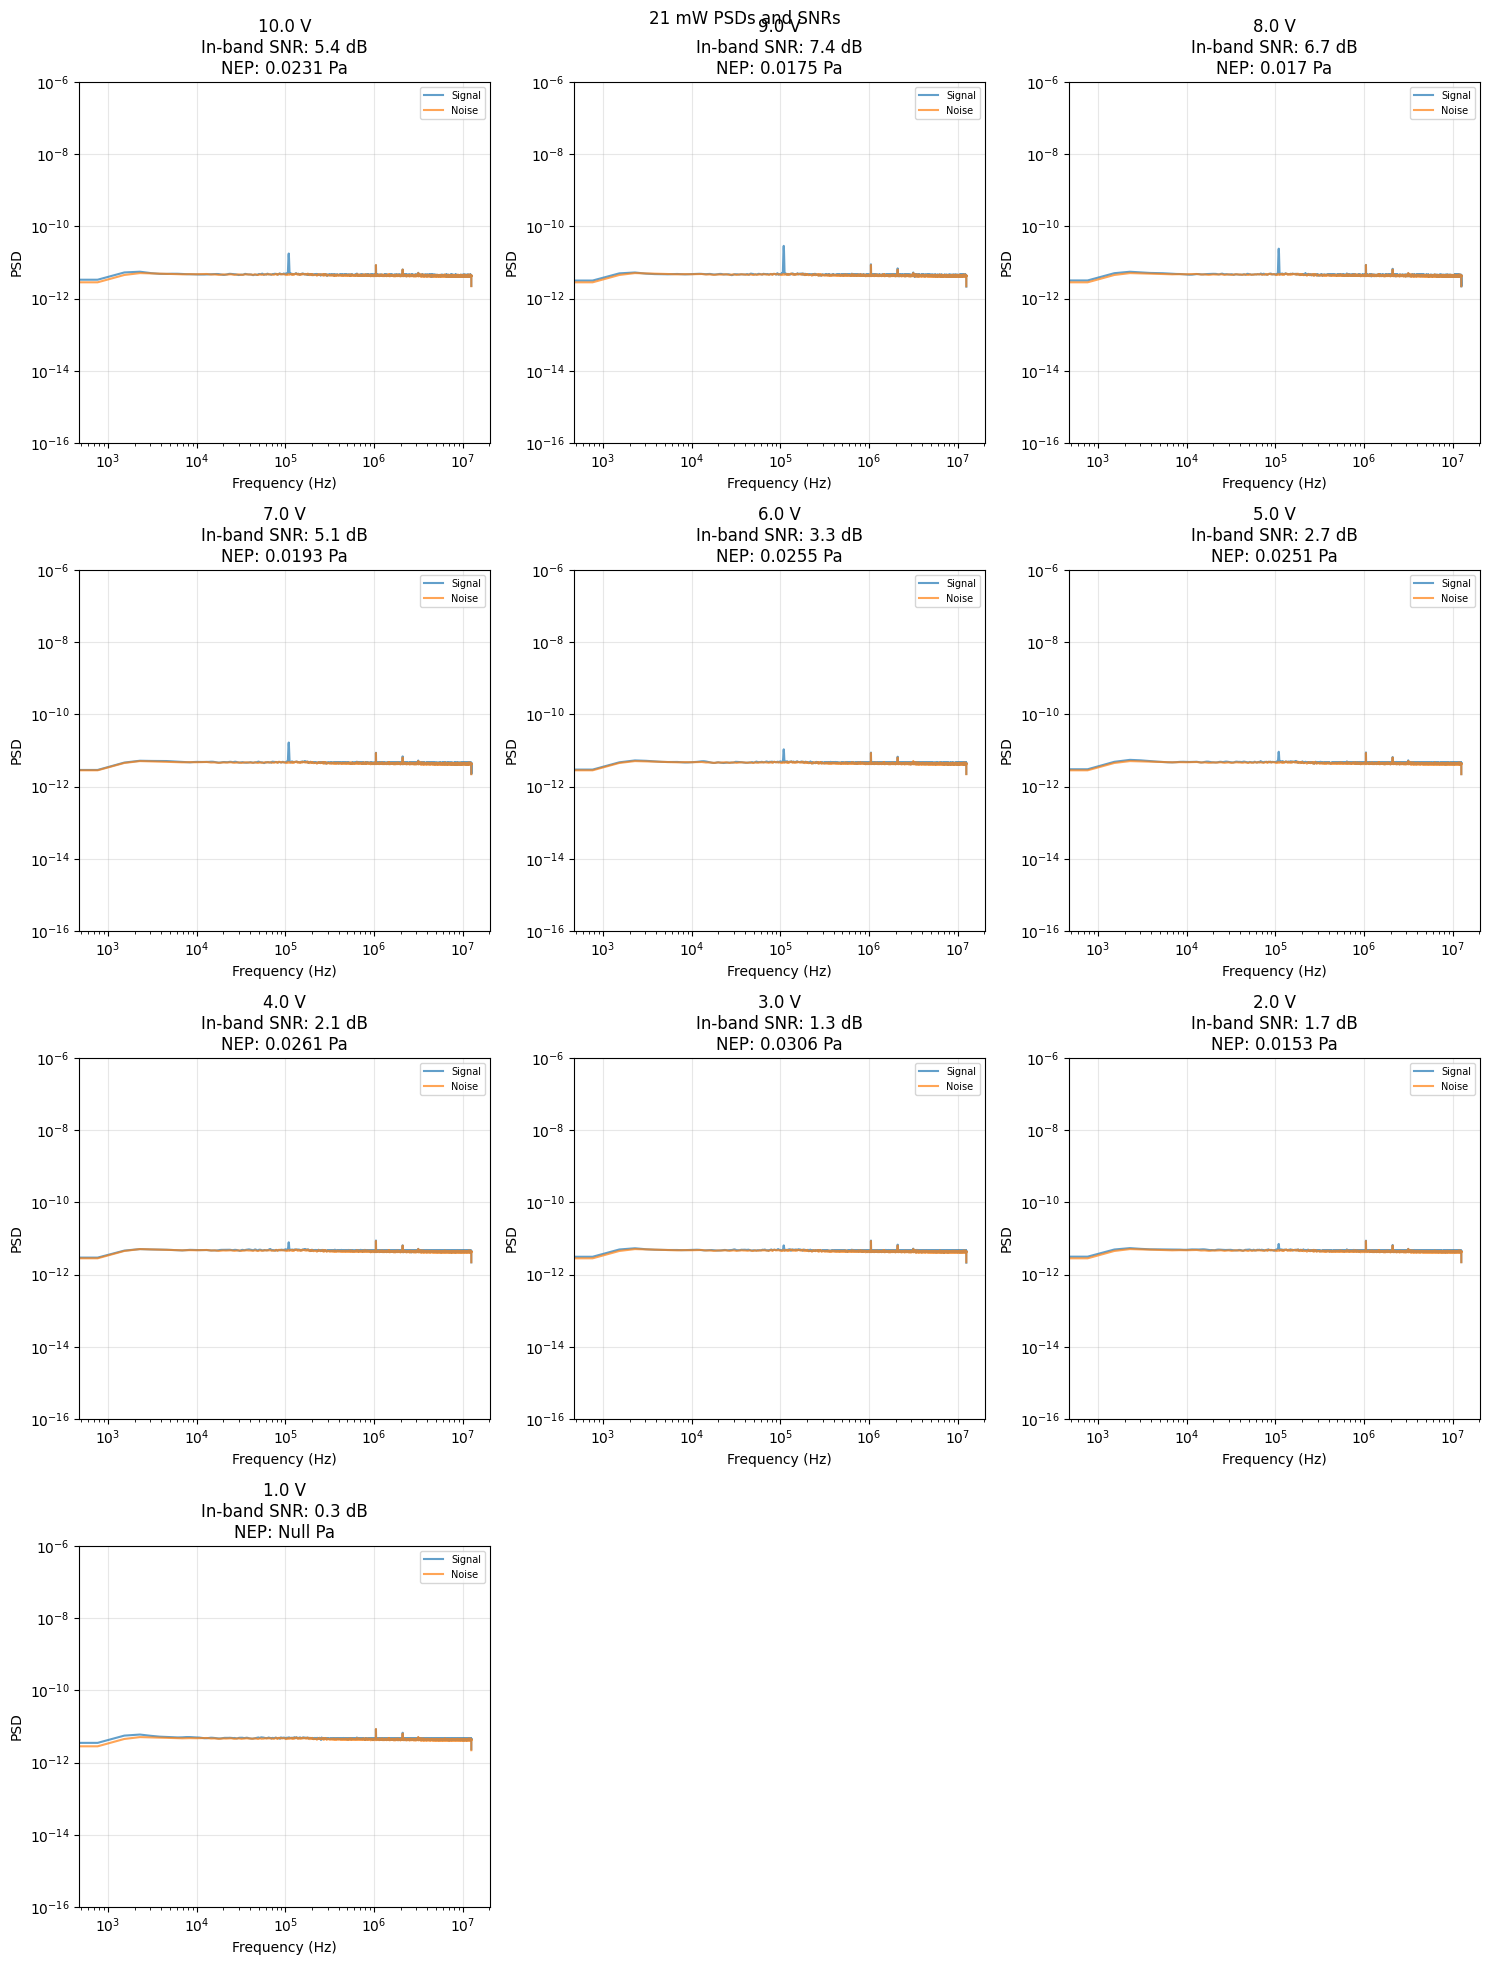

In [67]:
results_21mW = analyze_power_level(21, base_path)

Analyzing pof_15mW: found 11 voltage scans
  Processing pof_15mW_109kHz_10V with 5 signal files and 5 noise files
    In-band bounds (Hz): 108337 to 109863
    In-band SNR: 8.34 dB | Wideband SNR: 0.15 dB
    NEP: 0.0149 Pa
  Processing pof_15mW_109kHz_9V with 5 signal files and 5 noise files
    In-band bounds (Hz): 108337 to 109863
    In-band SNR: 4.31 dB | Wideband SNR: 0.17 dB
    NEP: 0.0302 Pa
  Processing pof_15mW_109kHz_8V with 5 signal files and 5 noise files
    In-band bounds (Hz): 108337 to 109863
    In-band SNR: 7.15 dB | Wideband SNR: 0.16 dB
    NEP: 0.0158 Pa
  Processing pof_15mW_109kHz_7V with 5 signal files and 5 noise files
    In-band bounds (Hz): 108337 to 109863
    In-band SNR: 4.36 dB | Wideband SNR: 0.16 dB
    NEP: 0.0227 Pa
  Processing pof_15mW_109kHz_6V with 5 signal files and 5 noise files
    In-band bounds (Hz): 108337 to 109863
    In-band SNR: 2.03 dB | Wideband SNR: 0.18 dB
    NEP: 0.0419 Pa
  Processing pof_15mW_109kHz_5V with 5 signal files and 

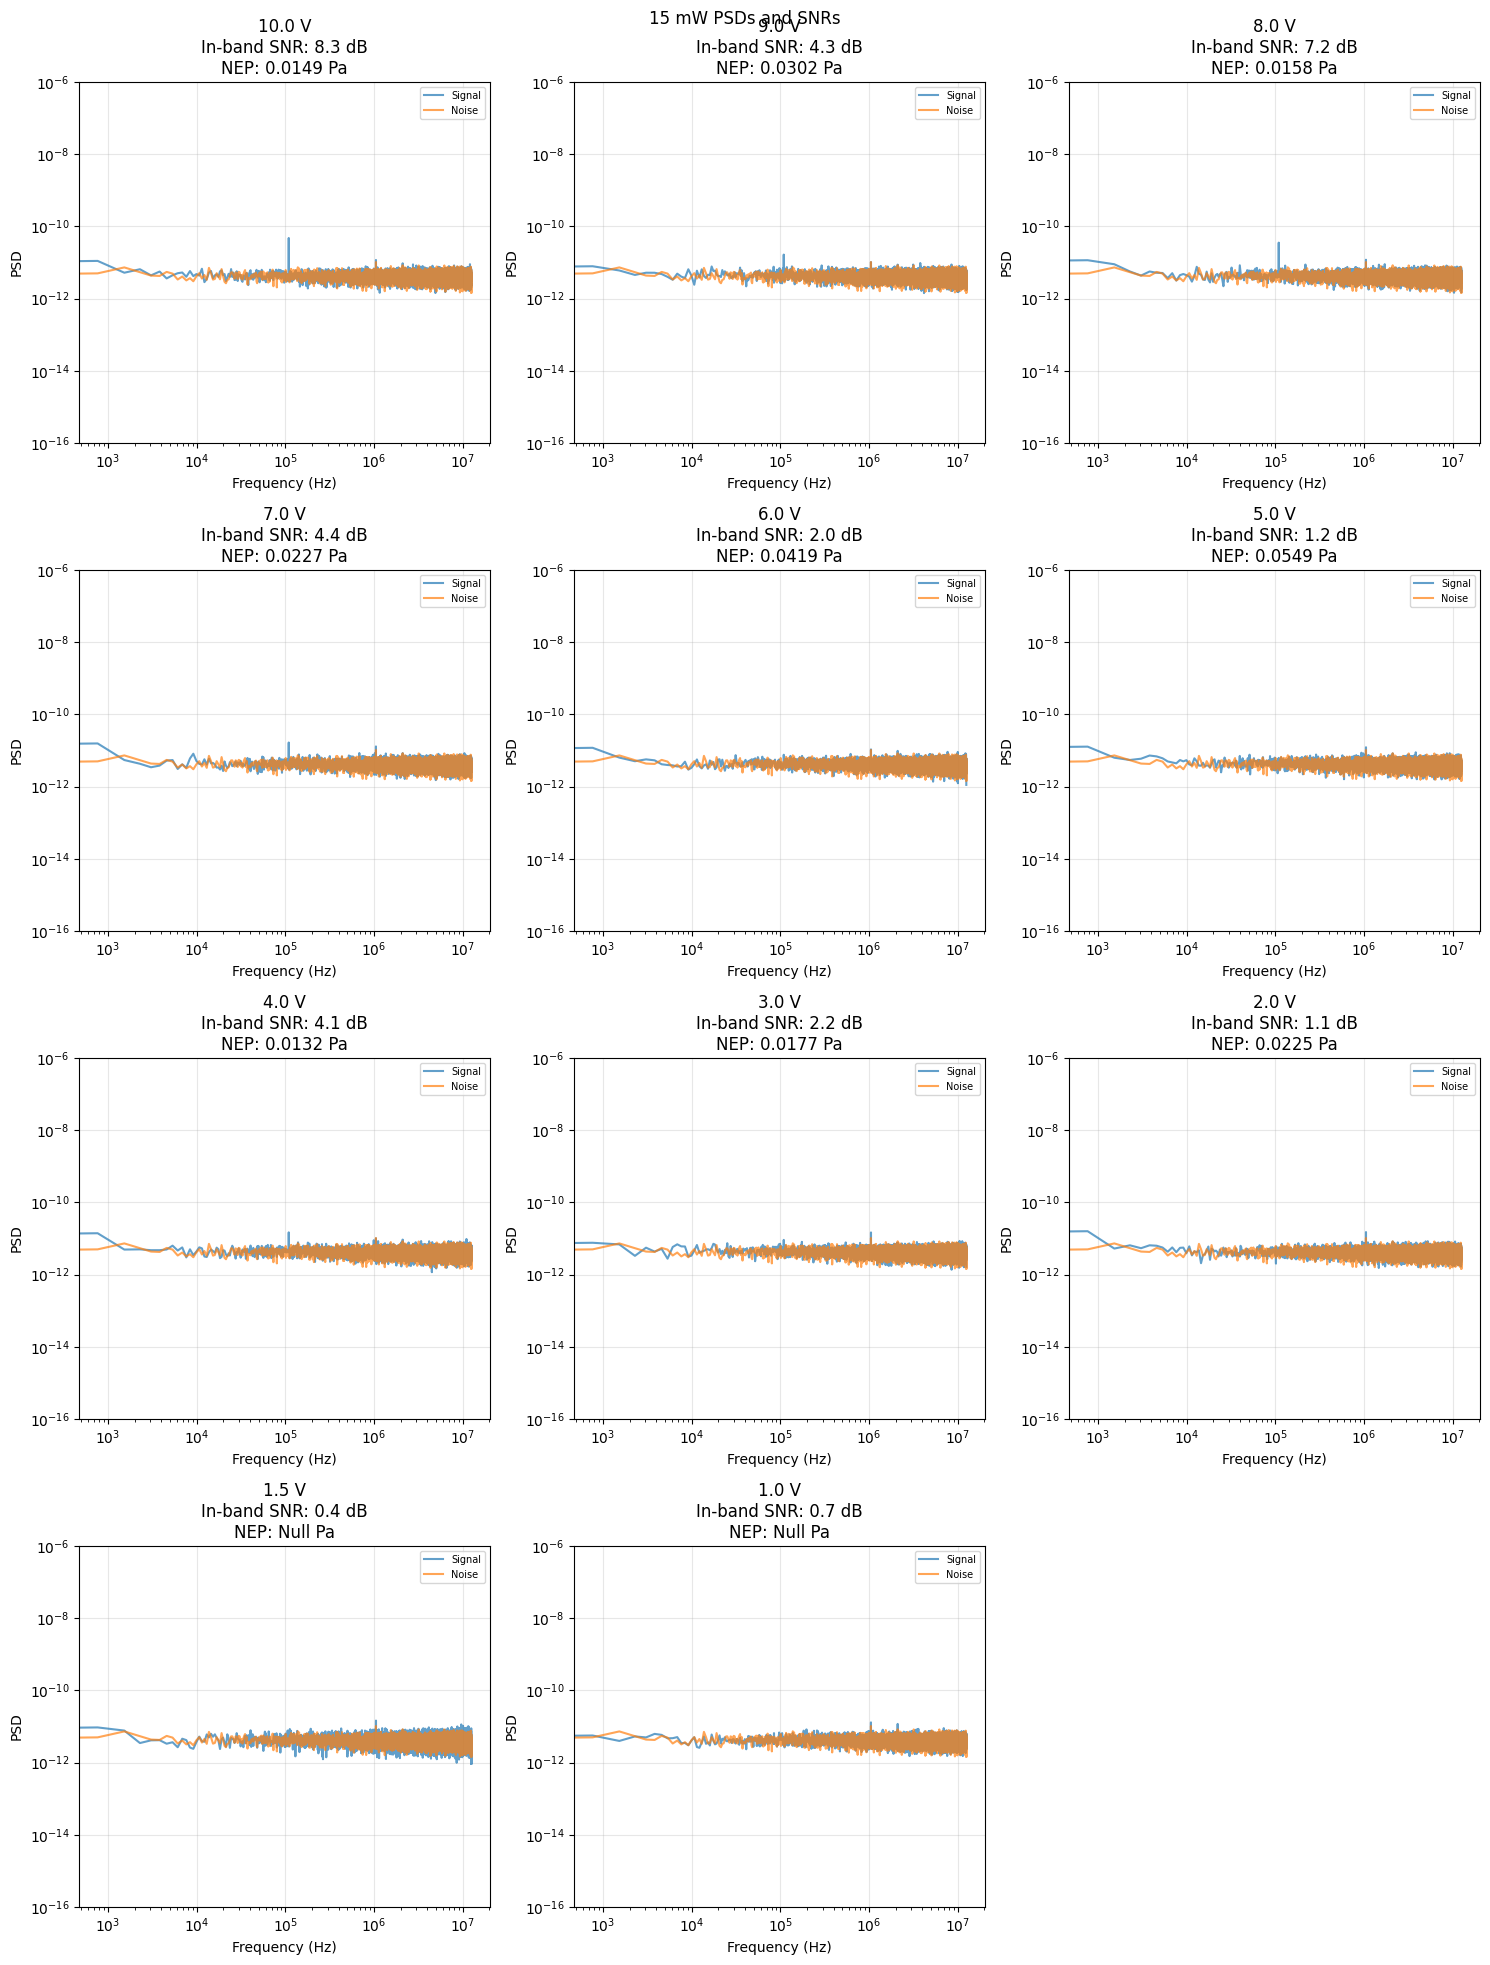

In [73]:
results_15mW = analyze_power_level(15, base_path)

Analyzing pof_10mW: found 10 voltage scans
  Processing pof_10mW_109kHz_10V with 5 signal files and 5 noise files
    In-band bounds (Hz): 108337 to 109863
    In-band SNR: 5.10 dB | Wideband SNR: 0.20 dB
    NEP: 0.0244 Pa
  Processing pof_10mW_109kHz_9V with 5 signal files and 5 noise files
    In-band bounds (Hz): 108337 to 109863
    In-band SNR: 6.05 dB | Wideband SNR: 0.18 dB
    NEP: 0.0215 Pa
  Processing pof_10mW_109kHz_8V with 5 signal files and 5 noise files
    In-band bounds (Hz): 108337 to 109863
    In-band SNR: 3.23 dB | Wideband SNR: 0.15 dB
    NEP: 0.035 Pa
  Processing pof_10mW_109kHz_7V with 5 signal files and 5 noise files
    In-band bounds (Hz): 108337 to 109863
    In-band SNR: 3.86 dB | Wideband SNR: 0.14 dB
    NEP: 0.0257 Pa
  Processing pof_10mW_109kHz_6V with 5 signal files and 5 noise files
    In-band bounds (Hz): 108337 to 109863
    In-band SNR: 2.53 dB | Wideband SNR: 0.06 dB
    NEP: 0.0336 Pa
  Processing pof_10mW_109kHz_5V with 5 signal files and 5

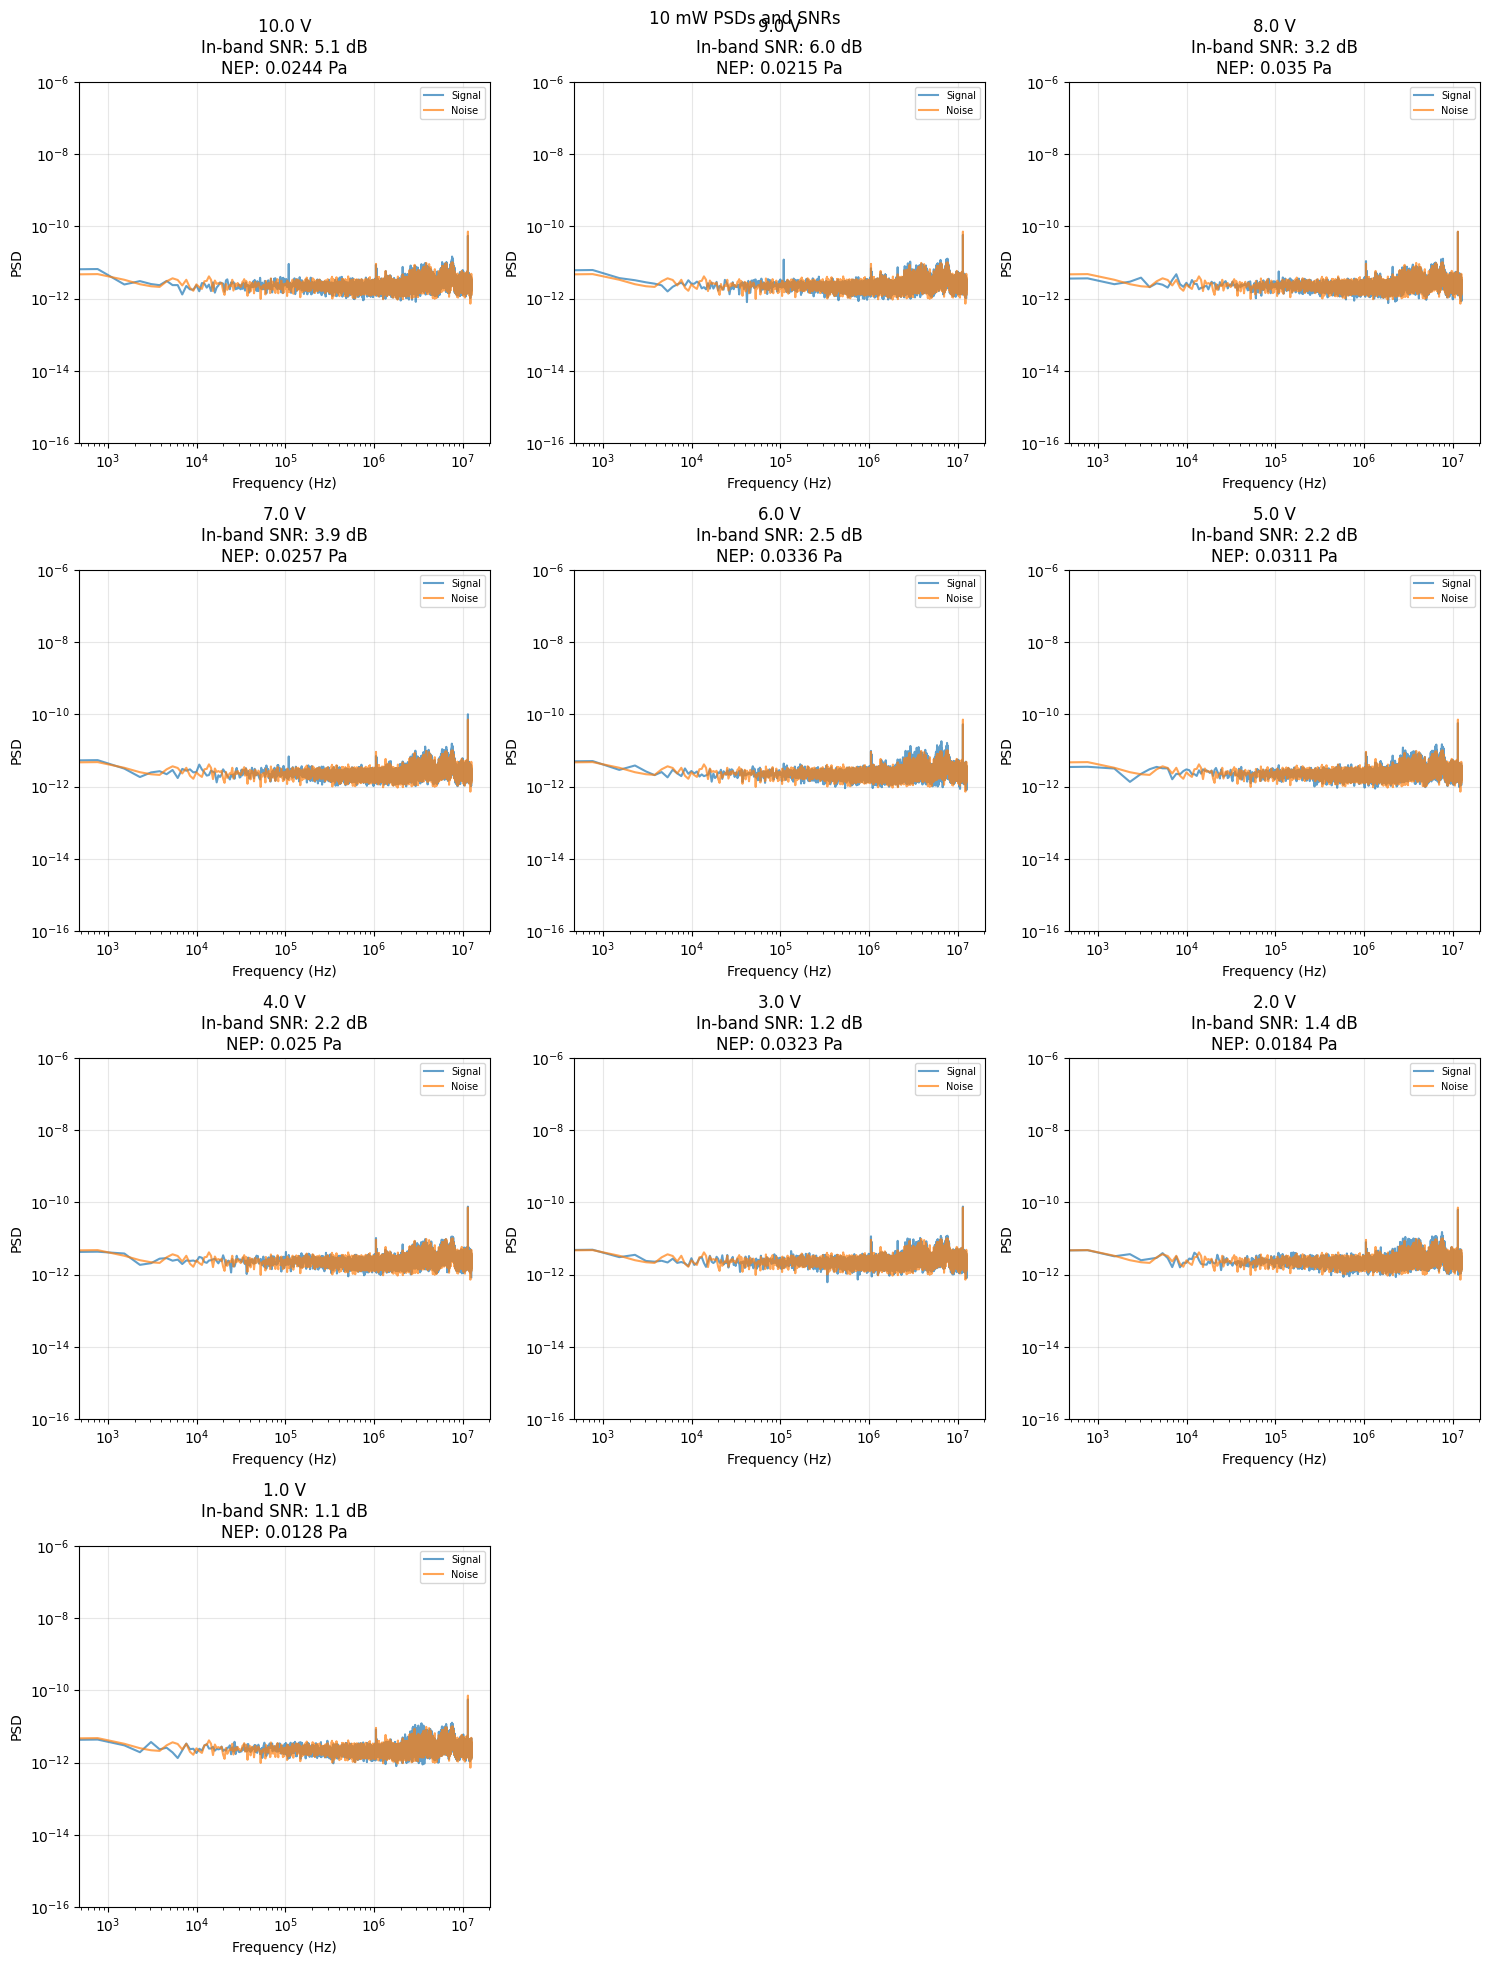

In [74]:
results_10mW = analyze_power_level(10, base_path)

Analyzing pof_5mW: found 10 voltage scans
  Processing pof_5mW_109kHz_10V with 5 signal files and 5 noise files
    In-band bounds (Hz): 108337 to 109863
    In-band SNR: 1.56 dB | Wideband SNR: -0.02 dB
    NEP: 0.0798 Pa
  Processing pof_5mW_109kHz_9V with 5 signal files and 5 noise files
    In-band bounds (Hz): 108337 to 109863
    In-band SNR: 1.43 dB | Wideband SNR: -0.02 dB
    NEP: 0.091 Pa
  Processing pof_5mW_109kHz_8V with 5 signal files and 5 noise files
    In-band bounds (Hz): 108337 to 109863
    In-band SNR: 1.00 dB | Wideband SNR: -0.02 dB
    NEP: 0.1132 Pa
  Processing pof_5mW_109kHz_7V with 5 signal files and 5 noise files
    In-band bounds (Hz): 108337 to 109863
    In-band SNR: 0.03 dB | Wideband SNR: -0.06 dB
    NEP: Null Pa
  Processing pof_5mW_109kHz_6V with 5 signal files and 5 noise files
    In-band bounds (Hz): 108337 to 109863
    In-band SNR: -0.19 dB | Wideband SNR: -0.04 dB
    NEP: Null Pa
  Processing pof_5mW_109kHz_5V with 5 signal files and 5 nois

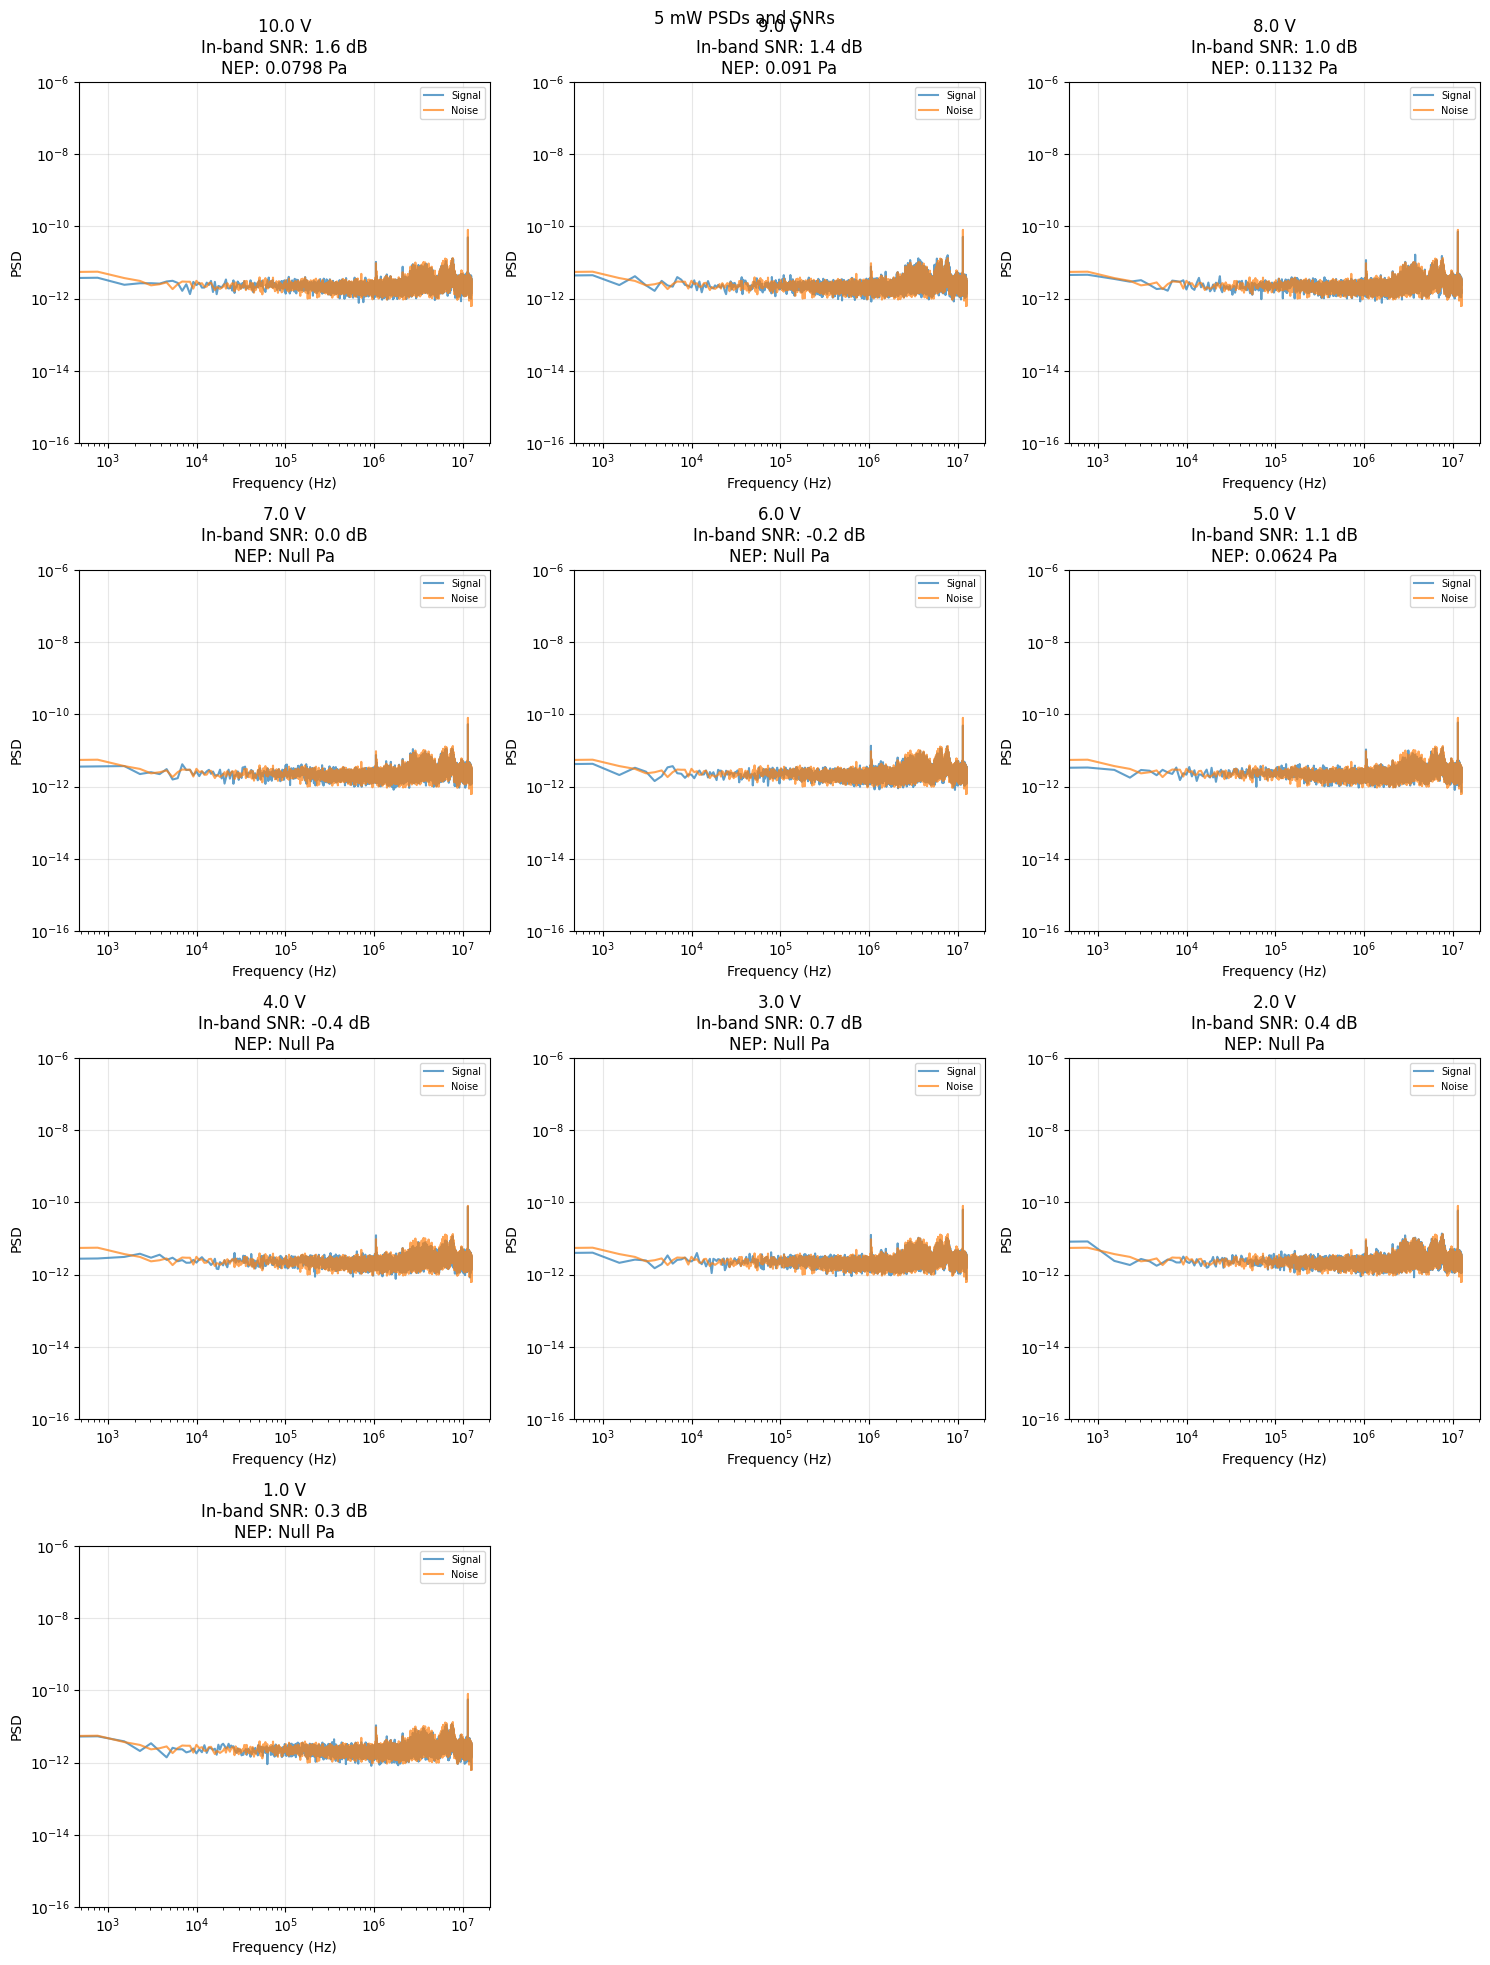

In [75]:
results_5mW = analyze_power_level(5, base_path)

Analyzing pof_4mW: found 6 voltage scans
  Processing pof_4mW_109kHz_10V with 5 signal files and 5 noise files
    In-band bounds (Hz): 108337 to 109863
    In-band SNR: 1.18 dB | Wideband SNR: -0.02 dB
    NEP: 0.1055 Pa
  Processing pof_4mW_109kHz_9V with 5 signal files and 5 noise files
    In-band bounds (Hz): 108337 to 109863
    In-band SNR: 0.01 dB | Wideband SNR: 0.03 dB
    NEP: Null Pa
  Processing pof_4mW_109kHz_8V with 5 signal files and 5 noise files
    In-band bounds (Hz): 108337 to 109863
    In-band SNR: 0.88 dB | Wideband SNR: 0.07 dB
    NEP: Null Pa
  Processing pof_4mW_109kHz_7V with 5 signal files and 5 noise files
    In-band bounds (Hz): 108337 to 109863
    In-band SNR: 0.40 dB | Wideband SNR: 0.01 dB
    NEP: Null Pa
  Processing pof_4mW_109kHz_6V with 5 signal files and 5 noise files
    In-band bounds (Hz): 108337 to 109863
    In-band SNR: 0.31 dB | Wideband SNR: 0.04 dB
    NEP: Null Pa
  Processing pof_4mW_109kHz_5V with 5 signal files and 5 noise files
 

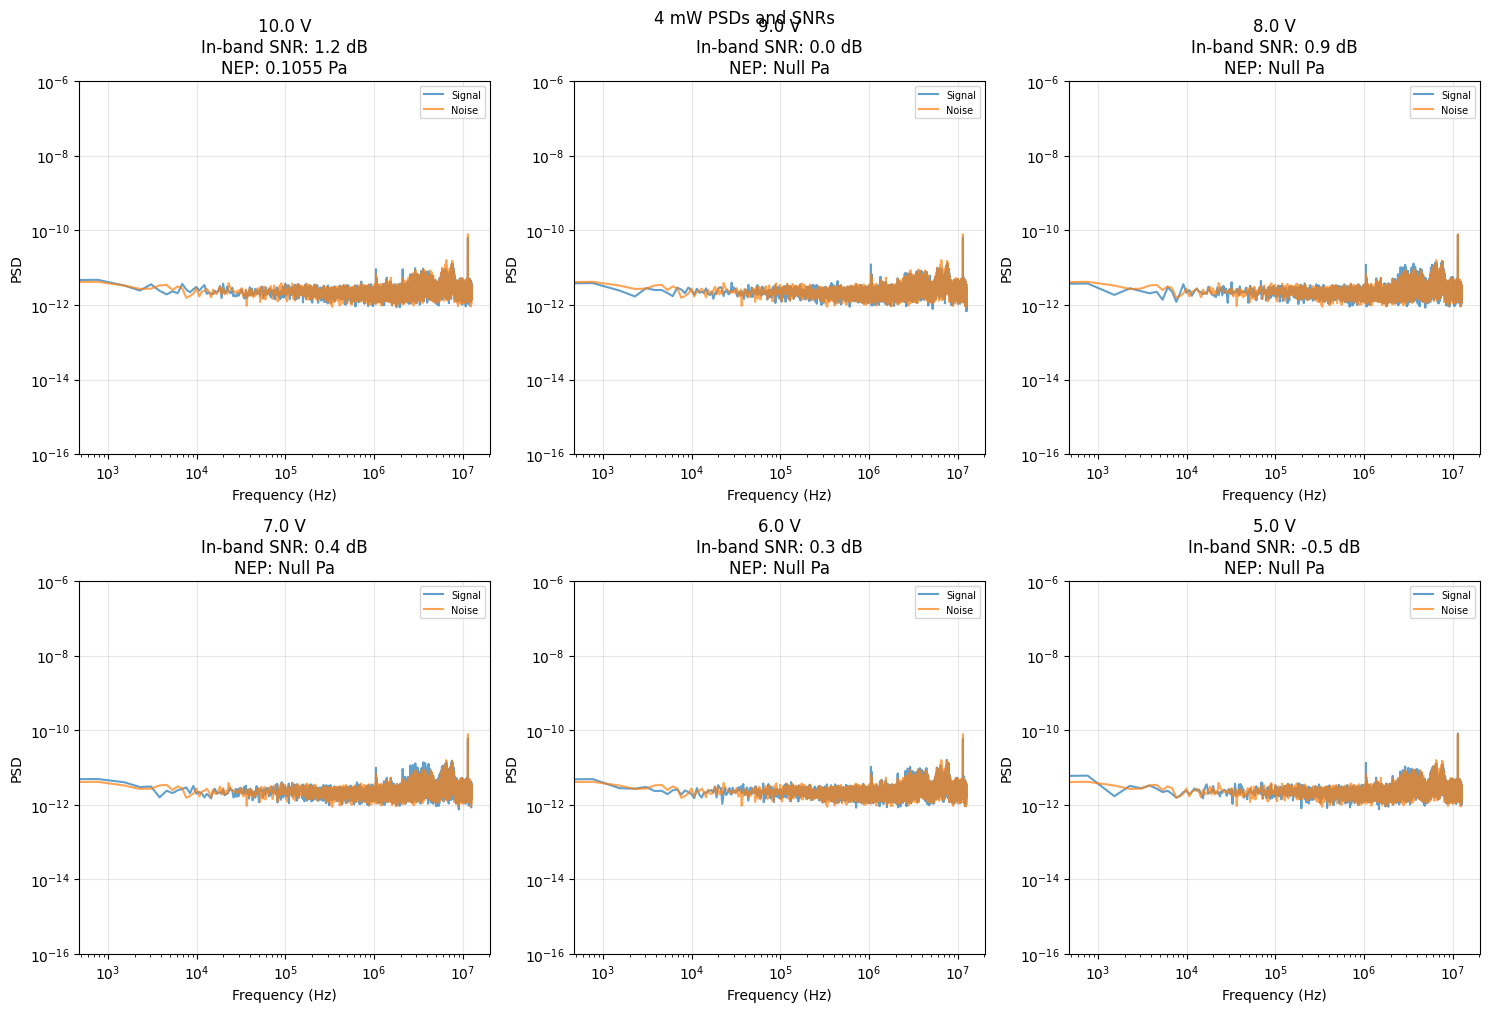

In [76]:
results_4mW = analyze_power_level(4, base_path)

Analyzing pof_3mW: found 6 voltage scans
  Processing pof_3mW_109kHz_10V with 5 signal files and 5 noise files
    In-band bounds (Hz): 108337 to 109863
    In-band SNR: 0.14 dB | Wideband SNR: -0.03 dB
    NEP: Null Pa
  Processing pof_3mW_109kHz_9V with 5 signal files and 5 noise files
    In-band bounds (Hz): 108337 to 109863
    In-band SNR: 0.46 dB | Wideband SNR: 0.02 dB
    NEP: Null Pa
  Processing pof_3mW_109kHz_8V with 5 signal files and 5 noise files
    In-band bounds (Hz): 108337 to 109863
    In-band SNR: 0.06 dB | Wideband SNR: 0.04 dB
    NEP: Null Pa
  Processing pof_3mW_109kHz_7V with 5 signal files and 5 noise files
    In-band bounds (Hz): 108337 to 109863
    In-band SNR: 0.04 dB | Wideband SNR: 0.01 dB
    NEP: Null Pa
  Processing pof_3mW_109kHz_6V with 5 signal files and 5 noise files
    In-band bounds (Hz): 108337 to 109863
    In-band SNR: 1.24 dB | Wideband SNR: 0.04 dB
    NEP: 0.0685 Pa
  Processing pof_3mW_109kHz_5V with 5 signal files and 5 noise files
 

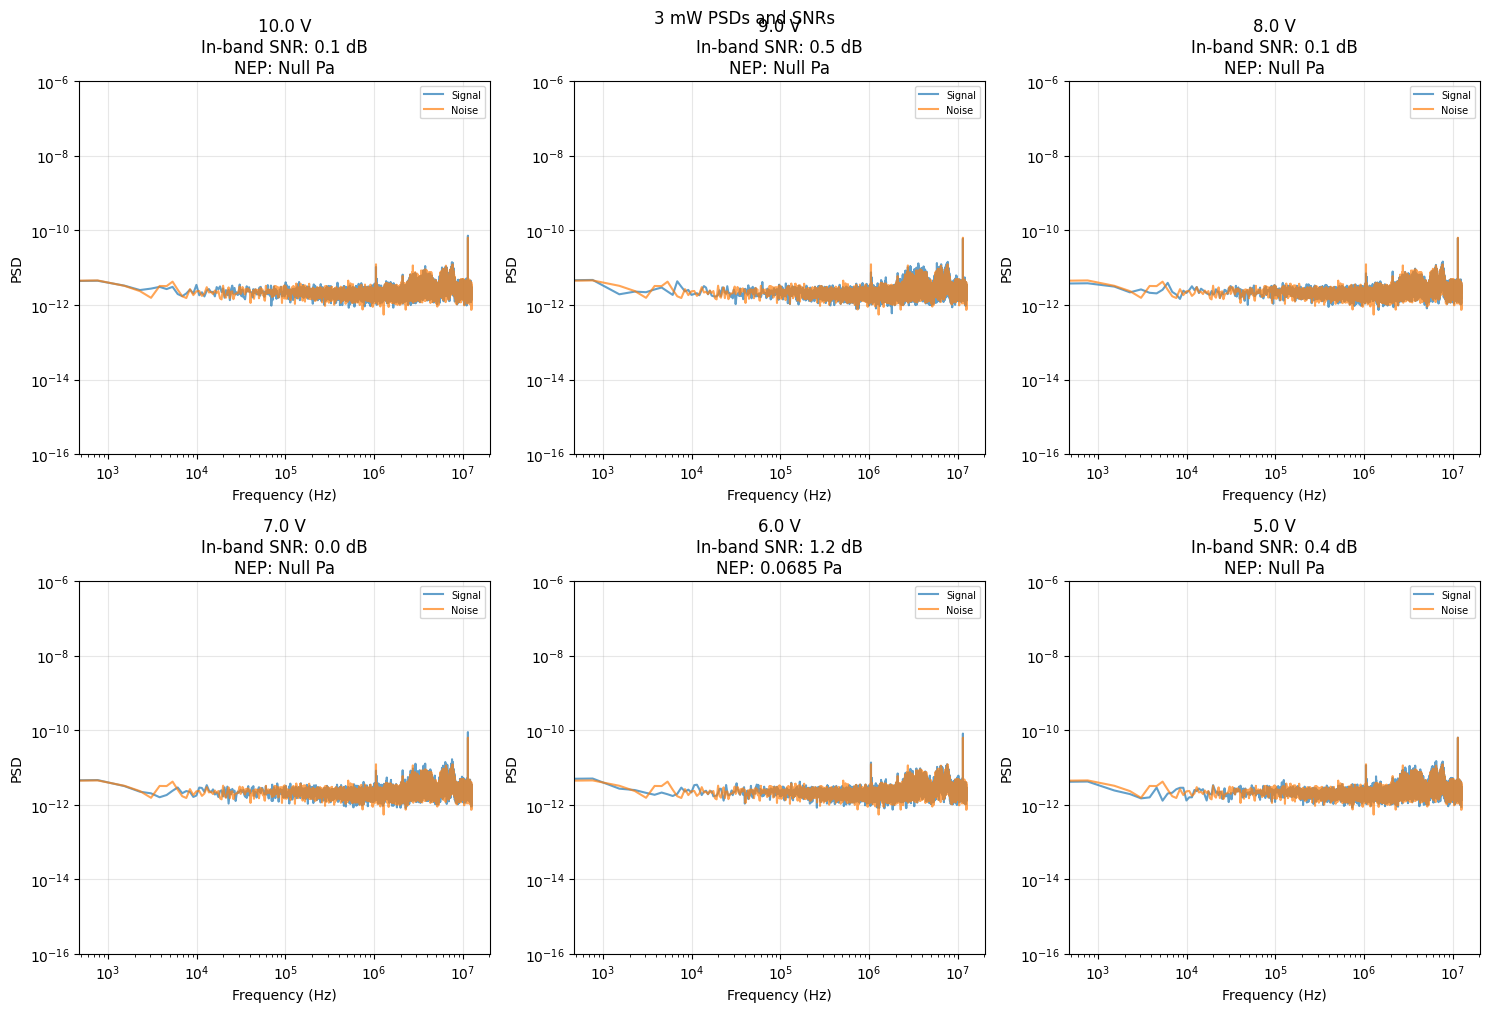

In [77]:
results_3mW = analyze_power_level(3, base_path)

Analyzing pof_2mW: found 1 voltage scans
  Processing pof_2mW_109kHz_10V with 5 signal files and 5 noise files
    In-band bounds (Hz): 108337 to 109863
    In-band SNR: -0.06 dB | Wideband SNR: -0.03 dB
    NEP: Null Pa


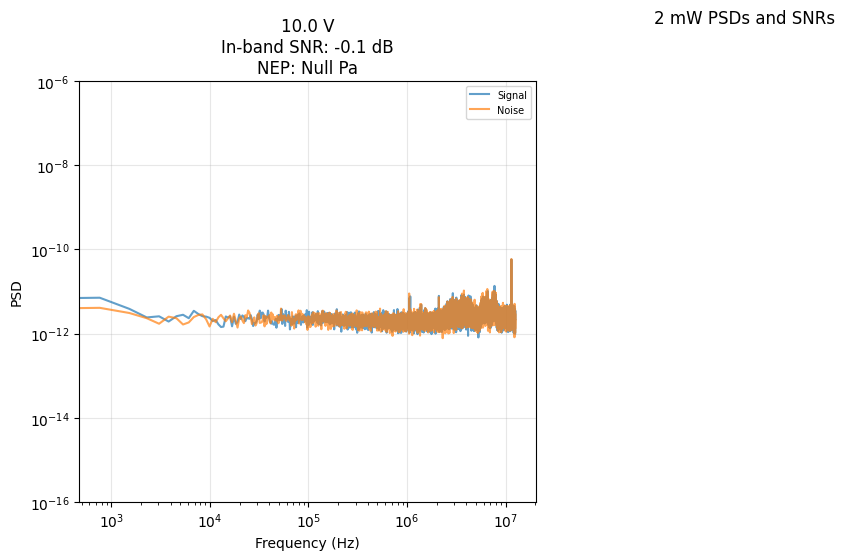

In [78]:
results_2mW = analyze_power_level(2, base_path)

pof_21mW_109kHz_10V: raw SNR=7.69, sub SNR=6.87, MF SNR=27.53
pof_21mW_109kHz_9V: raw SNR=9.52, sub SNR=9.01, MF SNR=29.57
pof_21mW_109kHz_8V: raw SNR=8.80, sub SNR=8.19, MF SNR=28.83
pof_21mW_109kHz_7V: raw SNR=6.38, sub SNR=5.25, MF SNR=26.03
pof_21mW_109kHz_6V: raw SNR=4.50, sub SNR=2.59, MF SNR=23.55
pof_21mW_109kHz_5V: raw SNR=4.54, sub SNR=2.66, MF SNR=22.43
pof_21mW_109kHz_4V: raw SNR=3.75, sub SNR=1.36, MF SNR=21.51
pof_21mW_109kHz_3V: raw SNR=2.06, sub SNR=-1.86, MF SNR=18.37
pof_21mW_109kHz_2V: raw SNR=2.15, sub SNR=-1.69, MF SNR=20.02
pof_21mW_109kHz_1V: raw SNR=0.74, sub SNR=-6.96, MF SNR=7.51


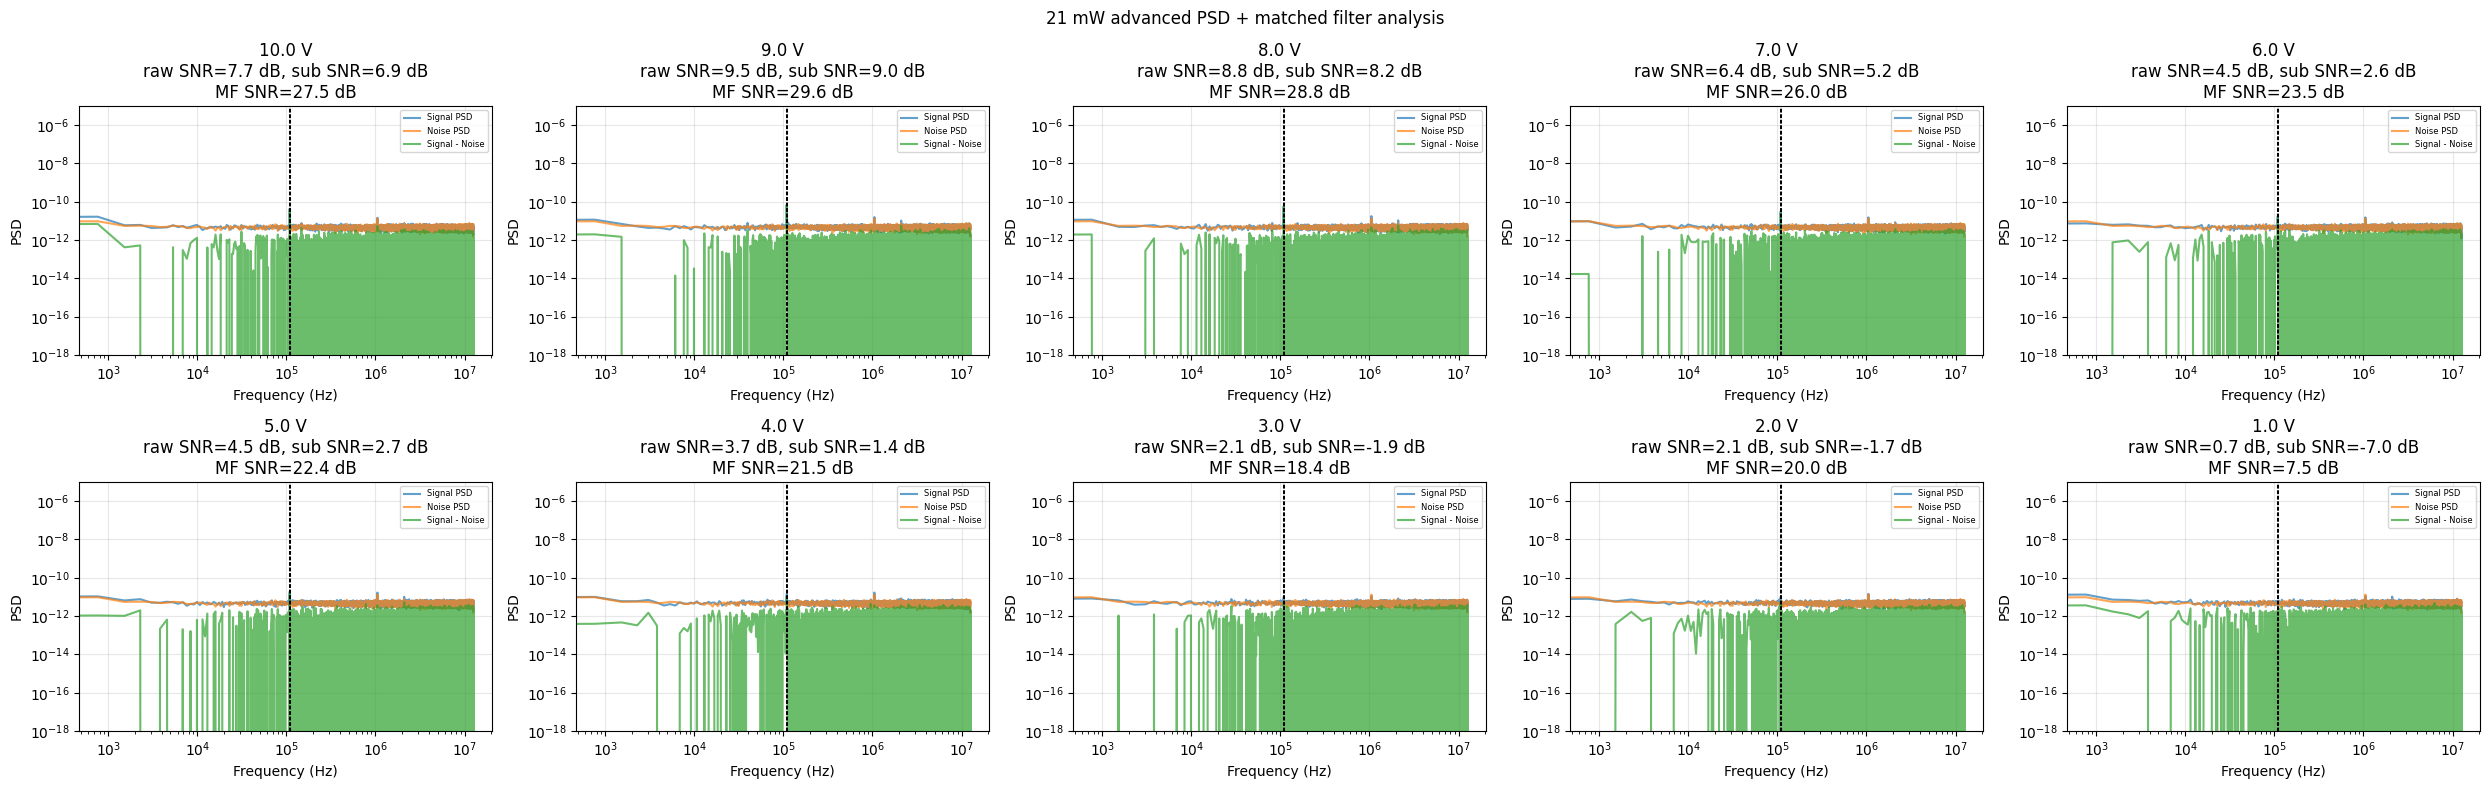

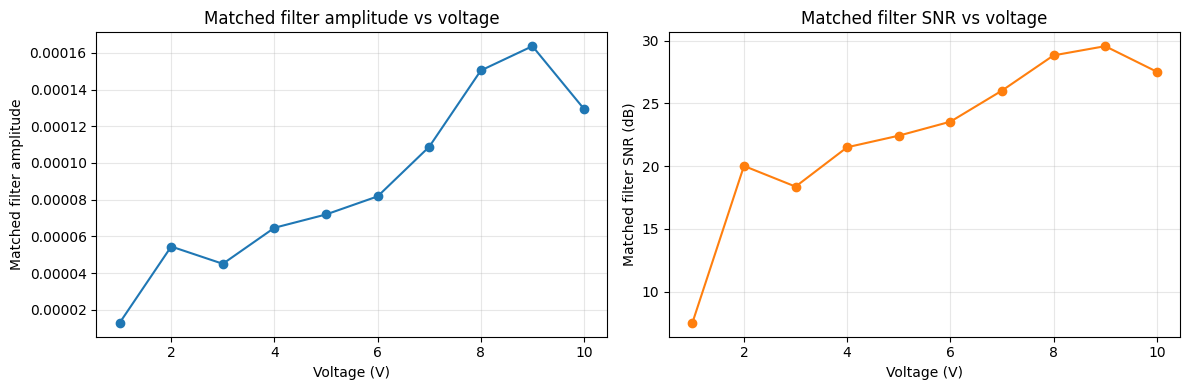

In [83]:
def matched_filter_amplitude(collection, center_frequency_hz):
    t = collection.t
    x = collection.x
    carrier = np.exp(-1j * 2 * np.pi * center_frequency_hz * t)
    return np.abs(np.mean(x * carrier))


def advanced_snr_analysis(power_mw, base_path, center_frequency_khz=109, band_half_width_hz=1e3):
    power_pattern = f"pof_{power_mw}mW"
    noise_folder = f"{power_pattern}_noise"

    voltage_folders = sorted(
        folder
        for folder in os.listdir(base_path)
        if os.path.isdir(os.path.join(base_path, folder))
        and folder.startswith(f"{power_pattern}_")
        and "noise" not in folder
        and re.search(r"_(\d+(?:\.\d+)?)V$", folder)
    )
    voltage_folders.sort(key=lambda folder: float(re.search(r"_(\d+(?:\.\d+)?)V$", folder).group(1)), reverse=True)

    if not voltage_folders:
        raise ValueError(f"No voltage scan folders found for {power_pattern}")

    center_frequency_hz = center_frequency_khz * 1e3
    rows, cols = 2, 5
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows), squeeze=False)
    axes = axes.flatten()

    voltage_values = []
    matched_filter_amplitudes = []
    matched_filter_snrs = []
    raw_snrs = []
    sub_snrs = []

    for ax, voltage_folder in zip(axes, voltage_folders):
        voltage_value = float(re.search(r"_(\d+(?:\.\d+)?)V$", voltage_folder).group(1))
        signal_path = os.path.join(base_path, voltage_folder)
        noise_path = os.path.join(base_path, noise_folder)

        signal_files = [
            os.path.join(signal_path, f"iter_{x}.tdms")
            for x in range(10)
            if os.path.exists(os.path.join(signal_path, f"iter_{x}.tdms"))
        ]
        noise_files = [
            os.path.join(noise_path, f"iter_{x}.tdms")
            for x in range(10)
            if os.path.exists(os.path.join(noise_path, f"iter_{x}.tdms"))
        ]

        if not signal_files or not noise_files:
            print(f"Skipping {voltage_folder}: missing signal or noise files")
            ax.set_visible(False)
            continue

        system = analysis.System(
            f"{power_pattern}_{voltage_folder}",
            signal_files + noise_files,
            channel="X",
            set_data=True,
        )

        freqs = None
        signal_psds = []
        noise_psds = []
        signal_mf = []
        noise_mf = []

        for dataset_idx, dataset in enumerate(system.get_data()):
            dataset.apply("detrend", mode="linear", inplace=True)
            group = "signal" if dataset_idx < len(signal_files) else "noise"

            for collection in dataset.collection:
                sample_rate = getattr(dataset, "r", None)
                if freqs is None:
                    freqs, psd = periodogram(collection.x, sample_rate, nfft=2**15)
                else:
                    _, psd = periodogram(collection.x, sample_rate, nfft=2**15)

                if group == "signal":
                    signal_psds.append(psd)
                    signal_mf.append(matched_filter_amplitude(collection, center_frequency_hz))
                else:
                    noise_psds.append(psd)
                    noise_mf.append(matched_filter_amplitude(collection, center_frequency_hz))

        avg_signal_psd = np.mean(np.asarray(signal_psds), axis=0)
        avg_noise_psd = np.mean(np.asarray(noise_psds), axis=0)
        signal_amplitude = np.mean(signal_mf)
        noise_amplitude = np.mean(noise_mf)

        noise_subtracted_psd = np.maximum(avg_signal_psd - avg_noise_psd, 0)
        band_min_idx = np.searchsorted(freqs, center_frequency_hz - band_half_width_hz)
        band_max_idx = np.searchsorted(freqs, center_frequency_hz + band_half_width_hz)

        raw_inband = np.trapezoid(avg_signal_psd[band_min_idx:band_max_idx], freqs[band_min_idx:band_max_idx])
        raw_noise_inband = np.trapezoid(avg_noise_psd[band_min_idx:band_max_idx], freqs[band_min_idx:band_max_idx])
        sub_inband = np.trapezoid(noise_subtracted_psd[band_min_idx:band_max_idx], freqs[band_min_idx:band_max_idx])

        snr_raw = 10 * np.log10(raw_inband / raw_noise_inband)
        snr_sub = 10 * np.log10(max(sub_inband, 1e-20) / raw_noise_inband)
        matched_filter_snr = 20 * np.log10(max(signal_amplitude / max(noise_amplitude, 1e-20), 1e-20))

        voltage_values.append(voltage_value)
        matched_filter_amplitudes.append(signal_amplitude)
        matched_filter_snrs.append(matched_filter_snr)
        raw_snrs.append(snr_raw)
        sub_snrs.append(snr_sub)

        ax.loglog(freqs, avg_signal_psd, label="Signal PSD", alpha=0.7)
        ax.loglog(freqs, avg_noise_psd, label="Noise PSD", alpha=0.7)
        ax.loglog(freqs, noise_subtracted_psd, label="Signal - Noise", alpha=0.7)
        ax.axvline(freqs[band_min_idx], color="k", linestyle="--", linewidth=0.75)
        ax.axvline(freqs[max(band_max_idx - 1, band_min_idx)], color="k", linestyle="--", linewidth=0.75)
        ax.set_title(
            f"{voltage_value} V\nraw SNR={snr_raw:.1f} dB, sub SNR={snr_sub:.1f} dB\nMF SNR={matched_filter_snr:.1f} dB"
        )
        ax.set_xlabel("Frequency (Hz)")
        ax.set_ylabel("PSD")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=6)
        ax.set_ylim(1e-18, 1e-5)

        print(f"{voltage_folder}: raw SNR={snr_raw:.2f}, sub SNR={snr_sub:.2f}, MF SNR={matched_filter_snr:.2f}")

    for ax in axes[len(voltage_folders):]:
        ax.set_visible(False)

    fig.suptitle(f"{power_mw} mW advanced PSD + matched filter analysis")
    fig.tight_layout()
    plt.show()

    if voltage_values:
        fig2, axes2 = plt.subplots(1, 2, figsize=(12, 4), squeeze=False)
        ax2 = axes2[0, 0]
        ax3 = axes2[0, 1]
        ax2.plot(voltage_values, matched_filter_amplitudes, 'o-', color='tab:blue', label='Matched filter amplitude')
        ax2.set_xlabel('Voltage (V)')
        ax2.set_ylabel('Matched filter amplitude')
        ax2.set_title('Matched filter amplitude vs voltage')
        ax2.grid(True, alpha=0.3)

        ax3.plot(voltage_values, matched_filter_snrs, 'o-', color='tab:orange', label='Matched filter SNR')
        ax3.set_xlabel('Voltage (V)')
        ax3.set_ylabel('Matched filter SNR (dB)')
        ax3.set_title('Matched filter SNR vs voltage')
        ax3.grid(True, alpha=0.3)

        fig2.tight_layout()
        plt.show()

    return

# Example: run the advanced analysis for one power level
advanced_snr_analysis(21, base_path)
